# Stock Volatility Predictor - EDA & Key Finding

Exploratory analysis of the feature set and the central result:
short-horizon realized volatility is only forecastable in proporation to how
much volatility actually moves. Calm years are nearly unpredictable; crisis 
regimes (2020) are highly unpredictable.

In [19]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ROOT = Path.cwd()
if ROOT.name == "notebooks": # robust whether launched from repo root or notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "src" / "data"))

from data.fetcher import load_config
from train import load_processed, make_fold_data
from evaluate import har_predictions, mincer_zarnowitz

cfg = load_config()
data = load_processed(cfg)
seq_len = cfg["windowing"]["seq_len"]
tickers = cfg["data"]["tickers"]
feature_names = cfg["features"]["columns"]
sqrt_ann = np.sqrt(cfg["target"]["annualization"])
sns.set_theme(style="whitegrid")

## 1. Data overview & volatility regimes

,rows,start,end,mean_fwd_vol,std_fwd_vol
SPY,2446,2015-04-07,2024-12-20,0.139297,0.115365
AAPL,2446,2015-04-07,2024-12-20,0.242361,0.158876
MSFT,2446,2015-04-07,2024-12-20,0.229627,0.158645
GOOGL,2446,2015-04-07,2024-12-20,0.24404,0.156353


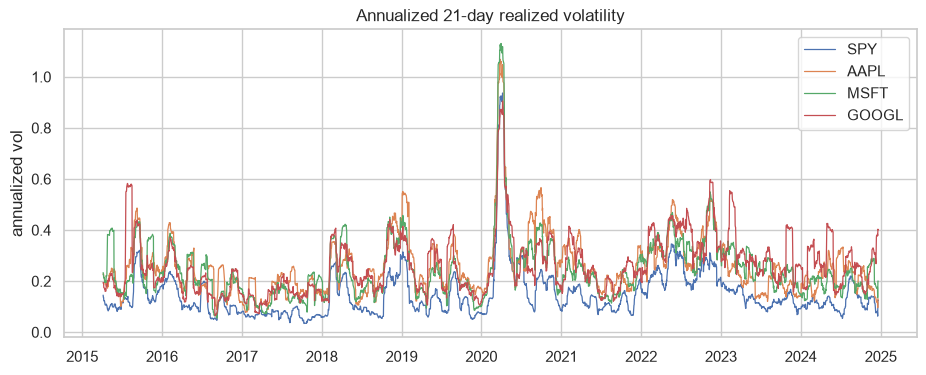

In [20]:
summary = pd.DataFrame({
    t: {
        "rows": len(data[t]["y"]),
        "start": pd.Timestamp(data[t]["dates"].min()).date(),
        "end": pd.Timestamp(data[t]["dates"].max()).date(),
        "mean_fwd_vol": data[t]["y"].mean(),
        "std_fwd_vol": data[t]["y"].std(),
    } for t in tickers
}).T
display(summary)

i_rv21 = feature_names.index("rv_21d")
fig, ax = plt.subplots(figsize=(11, 4))
for t in tickers: 
    ax.plot(pd.to_datetime(data[t]["dates"]), data[t]["X"][:, i_rv21] * sqrt_ann,
            label=t, lw=0.9)
ax.set_title("Annualized 21-day realized volatility")
ax.set_ylabel("annualized vol")
ax.legend()
plt.show()

## 2. Feature correlations (SPY)

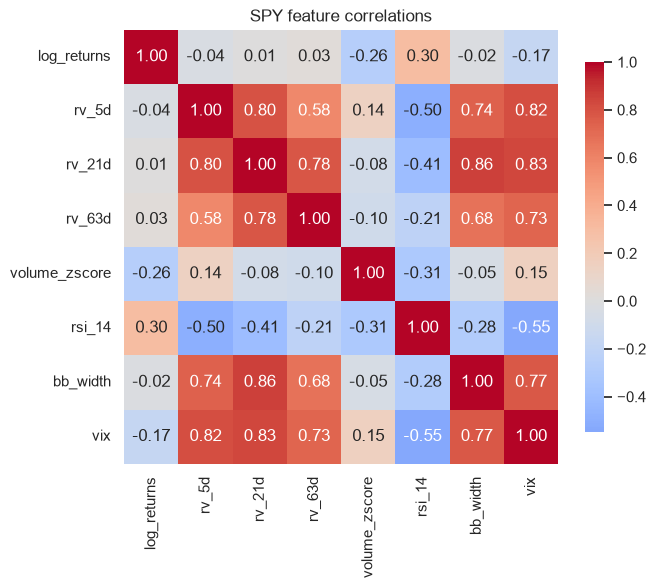

In [21]:
spy = pd.DataFrame(data["SPY"]["X"], columns=feature_names)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(spy.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("SPY feature correlations")
plt.show()

## 3. Key finding - forecastability tracks the vol regime

HAR-RV is re-fit on all data before each calendar year and scored within it
(per-ticker averaged). R^2 is near zero in calm years but jumps to ~0.32 in the 
2020 crash - which is why the single calm-2024 holdout understates the models.

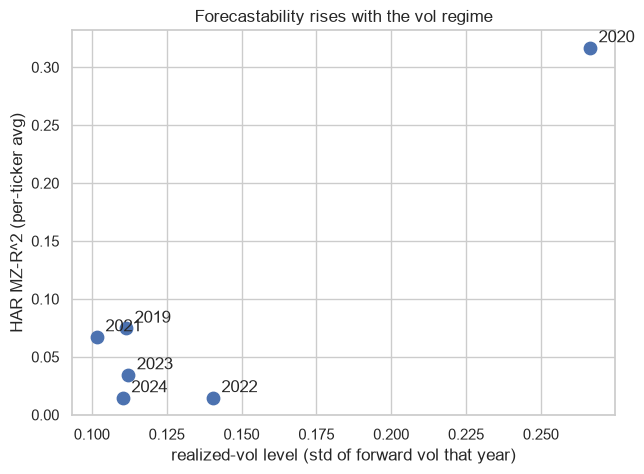

In [22]:
def ticker_index(start, end):
    s, e = np.datetime64(start), np.datetime64(end)
    labels = []
    for t, d in data.items():
        ld = d["dates"][seq_len - 1:]
        m = (ld >= s) & (ld < e)
        labels.append(np.full(int(m.sum()), t))
    return np.concatenate(labels)

years, ystds, r2s = [], [], []
for year in range(2019, 2025):
    start, end = pd.Timestamp(f"{year}-01-01"), pd.Timestamp(f"{year+1}-01-01")
    _, _, _, y = make_fold_data(data, start, end, seq_len)
    har = har_predictions(data, start, end, seq_len, cfg)
    tix = ticker_index(start, end)
    r2 = np.mean([mincer_zarnowitz(y[tix == t], har[tix == t])[0] for t in tickers])
    years.append(year); ystds.append(y.std()); r2s.append(r2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ystds, r2s, s=80)
for x, yv, yr in zip(ystds, r2s, years):
    ax.annotate(str(yr), (x, yv), textcoords="offset points", xytext=(6, 4))
ax.set_xlabel("realized-vol level (std of forward vol that year)")
ax.set_ylabel("HAR MZ-R^2 (per-ticker avg)")
ax.set_title("Forecastability rises with the vol regime")
plt.show()